# Initializations

General imports and seed initializations.

In [3]:
import urllib.request
import zipfile,tarfile,os
url = 'http://dihana.cps.unizar.es/~cadrete/curso_asr_unizar/musan_small.zip'
if not os.path.exists('musan_small.zip'):
    urllib.request.urlretrieve(url, 'musan_small.zip')
    with zipfile.ZipFile('musan_small.zip', 'r') as zip_ref:
        zip_ref.extractall()
url = 'http://dihana.cps.unizar.es/~cadrete/curso_asr_unizar/rirs_noises_small.zip'
if not os.path.exists('rirs_noises_small.zip'):
    urllib.request.urlretrieve(url, 'rirs_noises_small.zip')
    with zipfile.ZipFile('rirs_noises_small.zip', 'r') as zip_ref:
        zip_ref.extractall()
url = 'http://dihana.cps.unizar.es/~cadrete/curso_asr_unizar/data1.zip'
if not os.path.exists('data1.zip'):
    urllib.request.urlretrieve(url, 'data1.zip')
    with zipfile.ZipFile('data1.zip', 'r') as zip_ref:
        zip_ref.extractall()
url = 'http://dihana.cps.unizar.es/~cadrete/curso_asr_unizar/data2.zip'
if not os.path.exists('data2.zip'):
    urllib.request.urlretrieve(url, 'data2.zip')
    with zipfile.ZipFile('data2.zip', 'r') as zip_ref:
        zip_ref.extractall()
url = 'http://dihana.cps.unizar.es/~cadrete/curso_asr_unizar/data3.zip'
if not os.path.exists('data3.zip'):
    urllib.request.urlretrieve(url, 'data3.zip')
    with zipfile.ZipFile('data3.zip', 'r') as zip_ref:
        zip_ref.extractall()
url = 'http://dihana.cps.unizar.es/~cadrete/curso_asr_unizar/wav.zip'
if not os.path.exists('wav.zip'):
    urllib.request.urlretrieve(url, 'wav.zip')
    with zipfile.ZipFile('wav.zip', 'r') as zip_ref:
        zip_ref.extractall()

In [4]:
import torch, torchaudio, glob, os, random
import scipy.signal
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib
import IPython
def seed_everything(seed):      
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
seed_everything(42)

# Transformer Encoder+Decoder

The transformer encoder is a stack of self-attention and feed-forward layers.
The transformer decoder is a stack of self-attention, cross-attention and feed-forward layers.

In [5]:
class FeedForward(torch.nn.Module):
    def __init__(self, d_model=512, d_ff=1024, dropout=0.1, **kwargs):
        super().__init__()
        self.ff = torch.nn.Sequential(
            torch.nn.LayerNorm(d_model),
            torch.nn.Linear(d_model, d_ff),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(d_ff, d_model),
        )
        
    def forward(self, x):
        return self.ff(x)

class SelfAttention(torch.nn.Module):
    def __init__(self, d_model, n_heads=8, d_head=64, dropout=0.1, **kwargs):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head
        self.scale = torch.sqrt(torch.tensor(d_head, dtype=torch.float32))
        self.norm = torch.nn.LayerNorm(d_model)
        self.q_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.v_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.k_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.dropout = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(d_head*n_heads, d_model)

    def forward(self, x):
        x = self.norm(x)
        b = x.shape[0]
        q = self.q_linear(x).view(b, -1, self.n_heads, self.d_head)
        k = self.k_linear(x).view(b, -1, self.n_heads, self.d_head)
        v = self.v_linear(x).view(b, -1, self.n_heads, self.d_head) 

        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale
     
        att = scores.softmax(dim=-1)
        att = self.dropout(att)

        out = torch.einsum('bhij,bjhd->bihd', att, v).reshape(b, -1, self.n_heads*self.d_head)
        out = self.dropout(out)
        out = self.out(out)
        return out

class Encoder(torch.nn.Module):
    def __init__(self, nb_layers=6, **kwargs):
        super().__init__()        
        self.seq_len = kwargs['seq_len']
        self.pos = torch.nn.Parameter(torch.randn(1, self.seq_len, kwargs['d_model']))
        self.att = torch.nn.ModuleList([SelfAttention(**kwargs) for _ in range(nb_layers)])
        self.ff = torch.nn.ModuleList([FeedForward(**kwargs) for _ in range(nb_layers)])
        
    def forward(self, x):
        b, t, d = x.shape
        x = x + self.pos[:, :t, :]
        for att, ff in zip(self.att, self.ff):
            x = x + att(x)
            x = x + ff(x)            
        return x


class CausalSelfAttention(torch.nn.Module):
    def __init__(self, d_model, n_heads=8, d_head=64, dropout=0.1, **kwargs):
        super().__init__()
        self.seq_len = kwargs['seq_len']
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head
        self.scale = torch.sqrt(torch.tensor(d_head, dtype=torch.float32))
        self.norm = torch.nn.LayerNorm(d_model)
        self.q_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.v_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.k_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.dropout = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(d_head*n_heads, d_model)
        
        self.register_buffer("mask", torch.tril(torch.ones(self.seq_len, self.seq_len))[None, None, ...] == 0)
            

    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        q = self.q_linear(x).view(b, -1, self.n_heads, self.d_head)
        k = self.k_linear(x).view(b, -1, self.n_heads, self.d_head)
        v = self.v_linear(x).view(b, -1, self.n_heads, self.d_head) 

        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale
        
        scores = scores.masked_fill(self.mask[:,:,:n,:n], float('-inf'))
        att = scores.softmax(dim=-1)
        att = self.dropout(att)

        out = torch.einsum('bhij,bjhd->bihd', att, v).reshape(b, -1, self.n_heads*self.d_head)
        out = self.dropout(out)
        out = self.out(out)
        return out

class CrossAttention(torch.nn.Module):
    def __init__(self, d_model, n_heads=8, d_head=64, dropout=0.1, **kwargs):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head
        self.scale = torch.sqrt(torch.tensor(d_head, dtype=torch.float32))
        self.norm1 = torch.nn.LayerNorm(d_model)
        self.norm2 = torch.nn.LayerNorm(d_model)
        self.q_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.v_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.k_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.dropout = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(d_head*n_heads, d_model)
    
    def forward(self, x1, x2):
        x1 = self.norm1(x1)
        x2 = self.norm2(x2)  
        b = x1.shape[0]
        q = self.q_linear(x1).view(b, -1, self.n_heads, self.d_head)
        k = self.k_linear(x2).view(b, -1, self.n_heads, self.d_head)
        v = self.v_linear(x2).view(b, -1, self.n_heads, self.d_head) 

        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale
     
        att = scores.softmax(dim=-1)
        att = self.dropout(att)

        out = torch.einsum('bhij,bjhd->bihd', att, v).reshape(b, -1, self.n_heads*self.d_head)
        out = self.dropout(out)
        out = self.out(out)
        return out, att
    
class Decoder2Cross(torch.nn.Module):
    def __init__(self, nb_layers=6, **kwargs):
        super().__init__()        
        self.seq_len = kwargs['seq_len']
        self.pos = torch.nn.Parameter(torch.randn(1, self.seq_len, kwargs['d_model']))
        self.att = torch.nn.ModuleList([CausalSelfAttention(**kwargs) for _ in range(nb_layers)])
        self.cross_att1 = torch.nn.ModuleList([CrossAttention(**kwargs) for _ in range(nb_layers)])
        self.cross_att2 = torch.nn.ModuleList([CrossAttention(**kwargs) for _ in range(nb_layers)])
        self.ff = torch.nn.ModuleList([FeedForward(**kwargs) for _ in range(nb_layers)])
        
    def forward(self, x, enc1, enc2):
        b, t, d = x.shape
        x = x + self.pos[:, :t, :]
        for att, cross_att1, cross_att2, ff in zip(self.att, self.cross_att1, self.cross_att2, self.ff):
            x = x + att(x)
            x = x + cross_att1(x, enc1)[0]
            x = x + cross_att2(x, enc2)[0]
            x = x + ff(x)            
        return x

class SpecAug(torch.nn.Module):
    def __init__(self, prob_t_warp=0.5,
                       t_factor=(0.9, 1.1), 
                       f_mask_width = (0, 8), 
                       t_mask_width = (0, 10),
                       nb_f_masks=[1,2], 
                       nb_t_masks=[1,2] ):
        super().__init__()
        self.t_factor = t_factor
        self.f_mask_width = f_mask_width
        self.t_mask_width = t_mask_width
        self.nb_f_masks = nb_f_masks
        self.nb_t_masks = nb_t_masks
        self.prob_t_warp = prob_t_warp

    def time_warp(self, x):
        x = torch.nn.functional.interpolate(x, size=(int(x.shape[2]*np.random.uniform(*self.t_factor)), ))
        # print('warp', x.shape[2])
        return x
    
    def freq_mask(self, x):
        for _ in range(np.random.randint(*self.nb_f_masks)):
            f = np.random.randint(*self.f_mask_width)
            f0 = np.random.randint(0, x.shape[1]-f)
            # print('f', f0, f0+f)
            x[:,f0:f0+f,:] = 0
        return x

    def time_mask(self, x):
        for _ in range(np.random.randint(*self.nb_t_masks)):
            t = np.random.randint(*self.t_mask_width)
            t0 = np.random.randint(0, x.shape[2]-t)
            # print('t', t0, t0+t)
            x[:,:,t0:t0+t] = 0
        return x

    def forward(self, x):
        if np.random.uniform() < self.prob_t_warp:
            x = self.time_warp(x)
        x = self.freq_mask(x)
        x = self.time_mask(x)
        return x

# Feature Extractor

The feature extractor is composed of a log mel-spectrogram and a linear layer.

In [6]:
class AudioFeatures(torch.nn.Module):
    def __init__(self, feat_dim=80, d_model=512, **kwargs):
        super().__init__()
        self.fe = torchaudio.transforms.MelSpectrogram(
                        n_fft=512, 
                        win_length=25*16, 
                        hop_length=10*16, 
                        n_mels=feat_dim)                            # 25ms window, 10ms shift
        self.spec_aug = SpecAug()
        self.linear = torch.nn.Linear(feat_dim, d_model)

    def forward(self, x): 
        x = self.fe(x)        
        x = (x+1e-6).log()
        if self.training:
            x = self.spec_aug(x)
        x = x.transpose(1, 2)
        x = self.linear(x)
        return x


class VisualFeatures(torch.nn.Module):
    def __init__(self, d_model=512, **kwargs):
        super().__init__()
        self.conv = torch.nn.Conv2d(1, d_model, kernel_size=(24,24), stride=(1, 8),padding=(0,12))
                 
    def forward(self, x):
        return self.conv(x.unsqueeze(1)).squeeze(-2).transpose(-1,-2)

class AudioVisualTransformer(torch.nn.Module):
    def __init__(self, vocab_size=24, **kwargs):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = kwargs['seq_len']

        self.fe1 = AudioFeatures(**kwargs)
        self.enc1 = Encoder(**kwargs)
        
        self.fe2 = VisualFeatures(**kwargs)
        self.enc2 = Encoder(**kwargs)   
                
        self.emb = torch.nn.Embedding(vocab_size, kwargs['d_model'])
        self.dec = Decoder2Cross(**kwargs)
        self.out = torch.nn.Linear(kwargs['d_model'], vocab_size)
        

    def encoder(self, x1, x2):
        x1 = self.fe1(x1)
        x1 = self.enc1(x1)

        x2 = self.fe2(x2)
        x2 = self.enc2(x2)
        return x1, x2
    
    def decoder(self, y, enc1, enc2):
        y = self.emb(y)
        dec = self.dec(y, enc1, enc2)
        return self.out(dec)
    
    def forward(self, x1, x2, y):
        enc1, enc2 = self.encoder(x1, x2)
        return self.decoder(y, enc1, enc2)
                
    def loss(self, x1, x2, y):        
        logits = self(x1, x2, y[:,:-1])
        target = y[:,1:]
        loss = torch.nn.functional.cross_entropy(logits.reshape(-1, self.vocab_size), 
                                                 target.reshape(-1))
        return loss
    
           
    def generate(self, x1, x2):
        device = next(self.parameters()).device
        self.eval()
        y = [20,]
        with torch.no_grad():            
            enc1, enc2 = self.encoder(x1.to(device),x2.to(device))   
                        
            while y[-1] != 22 and len(y) < self.seq_len:
                logits = self.decoder(torch.tensor(y).unsqueeze(0).to(device), 
                                      enc1, enc2)
                y.append(logits.argmax(-1)[:,-1].item())
                            
        return y
    

# Dataset 

In [11]:
class NoiseAug(object):
    def __init__(self, noise_dir='musan_small/', prob=0.5):
        self.prob = prob
        self.noises = glob.glob(noise_dir+'/*/*.wav')
        
    def __call__(self, x):
        if np.random.uniform() < self.prob:
            n = torchaudio.load( np.random.choice(self.noises) )[0][0]            
            if len(n) < len(x):
                n = torch.nn.functional.pad(n, (0, len(x)-len(n)), value=0)
            elif len(n) > len(x):
                t0 = np.random.randint(0, len(n) - len(x))
                n = n[t0:t0+len(x)]
            n = n.numpy()
            p_x = x.std()**2
            p_n = n.std()**2
            snr = np.random.uniform(5, 15)
            n = n * np.sqrt(p_x/p_n) * np.power(10, -snr/20)
            x = x + n
        return x
    
class RIRAug(object):
    def __init__(self, rir_dir='RIRS_NOISES_small/simulated_rirs_small/', prob=0.5):
        self.prob = prob
        self.rirs = glob.glob(rir_dir+'/*.wav') 

    def __call__(self, x):
        if np.random.uniform() < self.prob:
            n = len(x)
            rir = torchaudio.load( np.random.choice(self.rirs) )[0][0]
            rir = rir.numpy()
            rir = rir / np.max(np.abs(rir))
            x = scipy.signal.convolve(x, rir)
            t0 = np.argmax(np.abs(rir))
            x = x[t0:t0+n]
        return x
    
class TrainDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir='data2/train', file_img='data3/digits_train.pt', audio_len=4*16000, transform=[], seq_len=10):        
        self.transform = transform
        self.audio_len = audio_len
        self.seq_len = seq_len
        self.files = sorted( glob.glob(data_dir+'/*.wav') )        
        print(len(self.files))
        self.img = torch.load(file_img, weights_only=False)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x1, fs = torchaudio.load(self.files[idx])
        if x1.shape[1] < self.audio_len:
            x1 = torch.nn.functional.pad(x1, (0, self.audio_len-x1.shape[1]), value=0)
        else:
            x1 = x1[:, :self.audio_len]

        x1 = x1[0].numpy()
        for t in self.transform:
            x1 = t(x1)
        
        x2 = torch.tensor(self.img[idx]).float() / 255

        label = self.files[idx].split('.')[-2].split('_')[-1]
        label = label.replace('o', '0')
        # print(x.shape, x.dtype)
        label = [int(d) for d in str(label)]
        y = [20, ] + label + [22, ]
        y = torch.nn.functional.pad(torch.tensor(y), (0, self.seq_len-len(y)), value=23)
        return x1, x2, y
    

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir='data2/test', file_img='data3/digits_test.pt', audio_len=4*16000, seq_len=10):
        self.audio_len = audio_len  
        self.seq_len = seq_len     
        self.files = sorted(glob.glob(data_dir+'/*.wav'))        
        print(len(self.files))
        self.img = torch.load(file_img, weights_only=False)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x1, fs = torchaudio.load(self.files[idx])
        if x1.shape[1] < self.audio_len:
            x1 = torch.nn.functional.pad(x1, (0, self.audio_len-x1.shape[1]), value=0)
        else:
            x1 = x1[:, :self.audio_len]

        x1 = x1[0]
        x2 = torch.tensor(self.img[idx]).float() / 255
        label = self.files[idx].split('.')[-2].split('_')[-1]
        # print(x.shape, x.dtype)
        label = label.replace('o', '0')
        label = [int(d) for d in str(label)]
        y = [20, ] + label + [22, ]
        y = torch.nn.functional.pad(torch.tensor(y), (0, self.seq_len-len(y)), value=23)
        return x1, x2, y

trainset = TrainDataset(transform=[NoiseAug(), RIRAug()])
testset = TestDataset()

# test dataset shapes and types
# x1, x2, y = trainset[0]
# print(x1.shape, x1.dtype)
# print(x2.shape, x2.dtype)

# x1, x2, y = testset[0]
# print(x1.shape, x1.dtype)
# print(x2.shape, x2.dtype)

8000
2000


# Train the network

In [12]:
model = AudioVisualTransformer(vocab_size=24, d_model=256, nb_layers=8, 
                               d_ff=512, n_heads=8, d_head=32, dropout=0.1, seq_len=500)

# test the network
# print(model.generate( torch.randn(1, 64000 ), torch.randn(1, 24, 120 ) ))




device = 'cuda'
model.to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-4)


nb_epochs = 5
batch_size = 32
model.train()

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
for e in range(nb_epochs):
    avg_loss = 0
    for x1, x2, y in trainloader:
        x1 = x1.to(device)
        x2 = x2.to(device)
        y = y.to(device)
        opt.zero_grad()
        loss = model.loss(x1, x2, y)
        loss.backward()
        opt.step()
        avg_loss += loss.item()
    print('epoch %d/%d: avg_loss: %.2f' % (e,nb_epochs,avg_loss/len(trainloader)))
       
torch.save([model, opt], 'model31.pt')

epoch 0/5: avg_loss: 0.63
epoch 1/5: avg_loss: 0.12
epoch 2/5: avg_loss: 0.06
epoch 3/5: avg_loss: 0.03
epoch 4/5: avg_loss: 0.03


# Test the network

In [13]:
#[model, opt] = torch.load('model31.pt')
import jiwer
model.eval()
hyp_ = []
ref_ = []
for i,(x1, x2, y) in enumerate(testset):    
    x1 = x1.to(device)    
    x2 = x2.to(device)    
    y_pred = model.generate(x1[None,...],x2[None,...])

    hyp = ' '.join([str(i) for i in y_pred[1:-1]])
    y = y.numpy().tolist()
    # find the first 22 <eos> in list y
    y = y[:y.index(22)]
    ref = ' '.join([str(i) for i in y[1:]])
    
    # print('(%d/%d)' % (i, len(testset)) )
    # print('ref', ref)
    # print('hyp', hyp)
    
    hyp_.append(hyp)
    ref_.append(ref)
    
out = jiwer.process_words(ref_, hyp_)
print(f"WER: {out.wer:.2%}")   

WER: 3.52%


# Visualize attention
We add a hook to cross attention layer to capture att tensors.

In [18]:
att1_ = [None] *  len(model.dec.cross_att1 )
for i, cross_att in enumerate(model.dec.cross_att1):
    cross_att.register_forward_hook(
        lambda _, ins, outs, index=i: att1_.__setitem__(index, outs[-1])
    )
att2_ = [None] *  len(model.dec.cross_att2 )
for i, cross_att in enumerate(model.dec.cross_att2):
    cross_att.register_forward_hook(
        lambda _, ins, outs, index=i: att2_.__setitem__(index, outs[-1])
    )
os.makedirs('out', exist_ok=True)

ejemplo 1 test set

ref 3 1 6 6
hyp 3 1 6 6


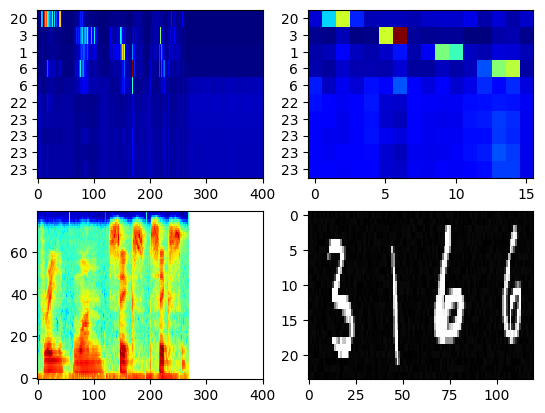

In [19]:
ifile = 1
x1, x2, y = testset[ifile]
x1 = x1.to(device)
x2 = x2.to(device)
y = y.to(device)
y_pred = model.generate(x1[None,...],x2[None,...])
model(x1[None,:], x2[None,:], y[None,:]) 
hyp = ' '.join([str(i) for i in y_pred[1:-1]])
y = y.cpu().numpy().tolist()
y0 = y
y = y[:y.index(22)]
ref = ' '.join([str(i) for i in y[1:]])
print('ref', ref)
print('hyp', hyp)

mean_att1 = torch.cat(att1_).mean([0, 1])
mean_att2 = torch.cat(att2_).mean([0, 1])

plt.clf()
plt.subplot(2,2,1)
plt.imshow(mean_att1.cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y0)), y0)
plt.subplot(2,2,3)
plt.imshow( model.fe1.fe(x1).log().detach().cpu().numpy(), interpolation='none', cmap='jet', aspect='auto',origin='lower')

plt.subplot(2,2,2)
plt.imshow(mean_att2.cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y0)), y0)
plt.subplot(2,2,4)
plt.imshow( x2.detach().cpu().numpy(), interpolation='none', cmap='gray', aspect='auto')

IPython.display.Audio(testset.files[ifile])

visualize attention

ref 9 1 7 1
hyp 9 1 7 1


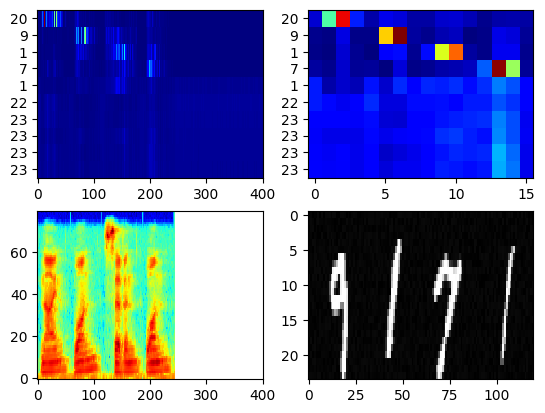

In [20]:
ifile = 700
x1, x2, y = testset[ifile]

x1 = x1.to(device)
x2 = x2.to(device)
y = y.to(device)
y_pred = model.generate(x1[None,...],x2[None,...])
model(x1[None,:], x2[None,:], y[None,:]) 
hyp = ' '.join([str(i) for i in y_pred[1:-1]])
y = y.cpu().numpy().tolist()
y0 = y
y = y[:y.index(22)]
ref = ' '.join([str(i) for i in y[1:]])
print('ref', ref)
print('hyp', hyp)

mean_att1 = torch.cat(att1_).mean([0, 1])
mean_att2 = torch.cat(att2_).mean([0, 1])

plt.clf()
plt.subplot(2,2,1)
plt.imshow(mean_att1.cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y0)), y0)
plt.subplot(2,2,3)
plt.imshow( model.fe1.fe(x1).log().detach().cpu().numpy(), interpolation='none', cmap='jet', aspect='auto',origin='lower')

plt.subplot(2,2,2)
plt.imshow(mean_att2.cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y0)), y0)
plt.subplot(2,2,4)
plt.imshow( x2.detach().cpu().numpy(), interpolation='none', cmap='gray', aspect='auto')


IPython.display.Audio(testset.files[ifile])

ref 3 7 5 7
hyp 3 7 5 7


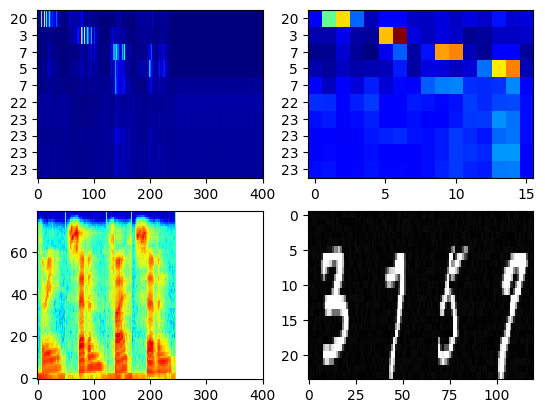

In [21]:
ifile = 133
x1, x2, y = testset[ifile]

x1 = x1.to(device)
x2 = x2.to(device)
y = y.to(device)
y_pred = model.generate(x1[None,...],x2[None,...])
model(x1[None,:], x2[None,:], y[None,:]) 
hyp = ' '.join([str(i) for i in y_pred[1:-1]])
y = y.cpu().numpy().tolist()
y0 = y
y = y[:y.index(22)]
ref = ' '.join([str(i) for i in y[1:]])
print('ref', ref)
print('hyp', hyp)

mean_att1 = torch.cat(att1_).mean([0, 1])
mean_att2 = torch.cat(att2_).mean([0, 1])

plt.clf()
plt.subplot(2,2,1)
plt.imshow(mean_att1.cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y0)), y0)
plt.subplot(2,2,3)
plt.imshow( model.fe1.fe(x1).log().detach().cpu().numpy(), interpolation='none', cmap='jet', aspect='auto',origin='lower')

plt.subplot(2,2,2)
plt.imshow(mean_att2.cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y0)), y0)
plt.subplot(2,2,4)
plt.imshow( x2.detach().cpu().numpy(), interpolation='none', cmap='gray', aspect='auto')


IPython.display.Audio(testset.files[ifile])